In [1]:
!pwd


/home/denizsen/awe/tests


In [2]:
cd ..

/home/denizsen/awe


In [3]:
import os
import numpy as np
import sys
sys.path.insert(0, '/home/denizsen/awe/robosuite')
from robosuite.environments.base import make
from robosuite.controllers import load_controller_config
from IPython.display import display, Image as IPImage
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import h5py
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import json
#from tqdm import tqdm
from tqdm.notebook import tqdm
from scipy.spatial.transform import Rotation
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.file_utils as FileUtils
from scipy.interpolate import CubicHermiteSpline
from waypoint_extraction.extract_waypoints import (
    greedy_waypoint_selection,
    dp_waypoint_selection,
    backtrack_waypoint_selection)

from waypoint_extraction.traj_reconstruction import point_line_distance



In [4]:
task = 'can' # lift, nut or square

if task == 'lift':
    env_name = 'Lift'
elif task == 'can':
    env_name = 'PickPlaceCan'
elif task == 'square':
    env_name = 'NutAssemblySquare'


### Data

In [5]:
#demo_path = f"/home/denizsen/awe/data/robomimic/datasets/{task}/ph/image_abs.hdf5"
# includes delta and since we ran conversion already also abs actions
demo_path = f"/home/denizsen/awe/robomimic/datasets/{task}/ph/low_dim.hdf5"
print(os.path.exists(demo_path))

True


In [6]:
with h5py.File(demo_path, "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)

data
data/demo_0
data/demo_0/abs_actions
data/demo_0/abs_obs
data/demo_0/abs_obs/object
data/demo_0/abs_obs/robot0_eef_pos
data/demo_0/abs_obs/robot0_eef_quat
data/demo_0/abs_obs/robot0_eef_vel_ang
data/demo_0/abs_obs/robot0_eef_vel_lin
data/demo_0/abs_obs/robot0_gripper_qpos
data/demo_0/abs_obs/robot0_gripper_qvel
data/demo_0/abs_obs/robot0_joint_pos
data/demo_0/abs_obs/robot0_joint_pos_cos
data/demo_0/abs_obs/robot0_joint_pos_sin
data/demo_0/abs_obs/robot0_joint_vel
data/demo_0/actions
data/demo_0/dones
data/demo_0/initial_state
data/demo_0/next_obs
data/demo_0/next_obs/object
data/demo_0/next_obs/robot0_eef_pos
data/demo_0/next_obs/robot0_eef_quat
data/demo_0/next_obs/robot0_eef_vel_ang
data/demo_0/next_obs/robot0_eef_vel_lin
data/demo_0/next_obs/robot0_gripper_qpos
data/demo_0/next_obs/robot0_gripper_qvel
data/demo_0/next_obs/robot0_joint_pos
data/demo_0/next_obs/robot0_joint_pos_cos
data/demo_0/next_obs/robot0_joint_pos_sin
data/demo_0/next_obs/robot0_joint_vel
data/demo_0/obs
dat

data/demo_130/obs
data/demo_130/obs/object
data/demo_130/obs/robot0_eef_pos
data/demo_130/obs/robot0_eef_quat
data/demo_130/obs/robot0_eef_vel_ang
data/demo_130/obs/robot0_eef_vel_lin
data/demo_130/obs/robot0_gripper_qpos
data/demo_130/obs/robot0_gripper_qvel
data/demo_130/obs/robot0_joint_pos
data/demo_130/obs/robot0_joint_pos_cos
data/demo_130/obs/robot0_joint_pos_sin
data/demo_130/obs/robot0_joint_vel
data/demo_130/rewards
data/demo_130/states
data/demo_130/waypoints_dp
data/demo_131
data/demo_131/abs_actions
data/demo_131/abs_obs
data/demo_131/abs_obs/object
data/demo_131/abs_obs/robot0_eef_pos
data/demo_131/abs_obs/robot0_eef_quat
data/demo_131/abs_obs/robot0_eef_vel_ang
data/demo_131/abs_obs/robot0_eef_vel_lin
data/demo_131/abs_obs/robot0_gripper_qpos
data/demo_131/abs_obs/robot0_gripper_qvel
data/demo_131/abs_obs/robot0_joint_pos
data/demo_131/abs_obs/robot0_joint_pos_cos
data/demo_131/abs_obs/robot0_joint_pos_sin
data/demo_131/abs_obs/robot0_joint_vel
data/demo_131/actions
data

### Convert Delta Actions to Absolute Actions
Note: AWE converts delta actions to abs actions and then computes waypoints

In [7]:
def convert_actions_to_abs(dataset_path: str, start_idx: int = 0, end_idx: int = 199, save: bool = True):
    """
    Converts delta actions to absolute (EEF pos/ori) actions.

    Args:
        dataset_path: Path to the HDF5 dataset file.
        start_idx:    First trajectory index to process (inclusive).
        end_idx:      Last trajectory index to process (inclusive).
        save:         If True, writes results back into the HDF5 file.
                      If False, returns a dict of results for inspection.
    """
    dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
    ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)

    env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
    env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render_offscreen=False)
    f = h5py.File(dataset_path, "r+" if save else "r")
    demos = list(f["data"].keys())
    inds = np.argsort([int(elem[5:]) for elem in demos])
    demos = [demos[i] for i in inds]

    assert start_idx >= 0 and end_idx < len(demos), (
        f"Index out of range: start={start_idx}, end={end_idx}, total={len(demos)}"
    )

    results = {}
    for idx in tqdm(range(start_idx, end_idx + 1), desc="Converting actions"):

        ep = demos[idx]
        states = f[f"data/{ep}/states"][()]
        traj_len = states.shape[0]

        delta_actions  = f[f"data/{ep}/actions"][()]
        action_pos     = np.zeros((traj_len, 3), dtype=delta_actions.dtype)
        action_ori     = np.zeros((traj_len, 3), dtype=delta_actions.dtype)
        action_gripper = delta_actions[:, -1:]

        obs = env.reset_to({"states": states[0]})
        obs = {k: [v] for k, v in obs.items()}

        robot      = env.env.robots[0]
        controller = robot.controller
        first      = True

        for i in range(traj_len):
            env.reset_to({"states": states[i]})
            robot.control(delta_actions[i], policy_step=True)

            if first:
                initial_state = env.get_state()["states"]
                first = False

            action_pos[i] = controller.ee_pos
            action_ori[i] = Rotation.from_matrix(controller.ee_ori_mat).as_rotvec()

            new_obs = env.get_observation()
            for k in obs:
                obs[k].append(new_obs[k])

        actions = np.concatenate([action_pos, action_ori, action_gripper], axis=-1)
        obs     = {k: np.stack(v, axis=0) for k, v in obs.items()}

        if save:
            f[f"data/{ep}/abs_actions"] = actions
            for k, v in obs.items():
                f[f"data/{ep}/abs_obs/{k}"] = v
            f[f"data/{ep}/initial_state"] = initial_state
        else:
            results[ep] = {
                "abs_actions":   actions,
                "abs_obs":       obs,
                "initial_state": initial_state,
            }

    f.close()

    if save:
        print(f"Done. Processed {end_idx - start_idx + 1} trajectories in '{dataset_path}'.")
    else:
        return results

In [8]:
abs_actions = convert_actions_to_abs(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=5,
    save=False
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name PickPlaceCan
Action size is 7


Converting actions:   0%|          | 0/6 [00:00<?, ?it/s]

In [9]:
with h5py.File(demo_path, "r") as f:
    for ep, data in abs_actions.items():
        saved_actions = f[f"data/{ep}/abs_actions"][()]
        diff = np.abs(data["abs_actions"] - saved_actions)
        print(f"{ep} — max diff: {diff.max():.6f}, mean diff: {diff.mean():.6f}")

demo_0 — max diff: 0.046809, mean diff: 0.000131
demo_1 — max diff: 0.000000, mean diff: 0.000000
demo_2 — max diff: 0.000000, mean diff: 0.000000
demo_3 — max diff: 0.000000, mean diff: 0.000000
demo_4 — max diff: 0.000000, mean diff: 0.000000
demo_5 — max diff: 0.000000, mean diff: 0.000000


In [10]:
WAYPOINT_METHODS = {
    "greedy":    greedy_waypoint_selection,
    "dp":        dp_waypoint_selection,
    "backtrack": backtrack_waypoint_selection,
}

def save_waypoints(
    dataset_path: str,
    start_idx:     int   = 0,
    end_idx:       int   = 199,
    method:        str   = "dp",
    err_threshold: float = 0.005,
    multiplier:    int   = 10,
    save:          bool  = True,
):
    """
    Selects waypoints from absolute actions for each trajectory.
    Args:
        dataset_path:  Path to the HDF5 dataset file (must already have abs_actions).
        start_idx:     First trajectory index to process (inclusive).
        end_idx:       Last trajectory index to process (inclusive).
        method:        Waypoint selection method: 'greedy', 'dp', or 'backtrack'.
        err_threshold: Error threshold for waypoint selection.
        multiplier:    Controller interpolation multiplier.
        save:          If True, writes waypoints back into the HDF5 file.
                       If False, returns a dict of results for inspection.
    """
    dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
    ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
    env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
    env_meta["env_kwargs"]["controller_configs"]["interpolation"] = "linear"
    env_meta["env_kwargs"]["controller_configs"]["control_delta"] = False
    env_meta["env_kwargs"]["controller_configs"]["multiplier"]    = multiplier
    env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render_offscreen=False)

    waypoint_selection = WAYPOINT_METHODS[method]

    f = h5py.File(dataset_path, "r+" if save else "r")
    demos = list(f["data"].keys())
    inds  = np.argsort([int(elem[5:]) for elem in demos])
    demos = [demos[i] for i in inds]
    assert start_idx >= 0 and end_idx < len(demos), (
        f"Index out of range: start={start_idx}, end={end_idx}, total={len(demos)}"
    )

    num_waypoints, num_frames = [], []
    results = {}

    for idx in tqdm(range(start_idx, end_idx + 1), desc="Saving waypoints"):
        ep       = demos[idx]
        states   = f[f"data/{ep}/states"][()]
        traj_len = states.shape[0]

        initial_states = [
            {"states": states[i], "model": f[f"data/{ep}"].attrs["model_file"]}
            for i in range(traj_len)
        ]

        eef_pos   = f[f"data/{ep}/obs/robot0_eef_pos"][()]
        eef_quat  = f[f"data/{ep}/obs/robot0_eef_quat"][()]
        joint_pos = f[f"data/{ep}/obs/robot0_joint_pos"][()]
        gt_states = [
            dict(
                robot0_eef_pos=eef_pos[i],
                robot0_eef_quat=eef_quat[i],
                robot0_joint_pos=joint_pos[i],
            )
            for i in range(traj_len)
        ]

        if f.get(f"data/{ep}/abs_actions") is None:
            raise RuntimeError(
                f"No abs_actions found for {ep}, run convert_actions_to_abs first."
            )
        actions = f[f"data/{ep}/abs_actions"][()]

        waypoints = waypoint_selection(
            env=env,
            actions=actions,
            gt_states=gt_states,
            err_threshold=err_threshold,
            initial_states=initial_states,
            remove_obj=True,
        )

        num_waypoints.append(len(waypoints))
        num_frames.append(traj_len)

        if save:
            key = f"data/{ep}/waypoints_{method}"
            if key in f:
                del f[key]
            f[key] = waypoints
        else:
            results[ep] = waypoints

    f.close()
    print(
        f"Average waypoints: {np.mean(num_waypoints):.1f}, "
        f"average frames: {np.mean(num_frames):.1f}, "
        f"waypoint ratio: {np.mean(num_frames) / np.mean(num_waypoints):.2f}x"
    )
    if not save:
        return results

In [11]:
waypoints_lin_dp = save_waypoints(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=4,
    save=False,
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name PickPlaceCan
Action size is 7


Saving waypoints:   0%|          | 0/5 [00:00<?, ?it/s]

Minimum number of waypoints: 25 	Trajectory Error: 5.516550207372527e-09
waypoint positions: [3, 9, 14, 20, 24, 29, 34, 38, 44, 51, 54, 60, 65, 71, 75, 80, 87, 92, 97, 103, 104, 108, 111, 114, 117]
Minimum number of waypoints: 25 	Trajectory Error: 3.5106816431912455e-08
waypoint positions: [2, 4, 8, 12, 18, 22, 27, 32, 38, 47, 53, 61, 68, 71, 74, 78, 84, 90, 94, 98, 103, 105, 109, 113, 117]
Minimum number of waypoints: 25 	Trajectory Error: 3.137094338710965e-08
waypoint positions: [4, 9, 13, 16, 22, 26, 31, 36, 42, 50, 58, 61, 67, 71, 75, 79, 85, 90, 94, 98, 99, 103, 105, 109, 112]
Minimum number of waypoints: 18 	Trajectory Error: 2.9718899998127628e-08
waypoint positions: [3, 9, 14, 21, 31, 41, 47, 56, 60, 64, 68, 72, 81, 84, 86, 90, 94, 97]
Minimum number of waypoints: 22 	Trajectory Error: 4.205848633795696e-09
waypoint positions: [4, 8, 14, 21, 27, 35, 41, 47, 52, 58, 62, 66, 70, 74, 78, 82, 87, 89, 93, 95, 97, 101]
Average waypoints: 23.0, average frames: 109.8, waypoint ratio:

In [12]:
with h5py.File(demo_path, "r") as f:
    for ep, wp_fresh in waypoints_lin_dp.items():
        wp_saved = f[f"data/{ep}/waypoints_dp"][()]
        match = np.array_equal(np.sort(wp_fresh), np.sort(wp_saved))
        print(f"{ep} — fresh: {len(wp_fresh)} waypoints, saved: {len(wp_saved)} waypoints, match: {match}")
        if not match:
            print(f"  fresh:  {sorted(wp_fresh)}")
            print(f"  saved:  {sorted(wp_saved)}")

demo_0 — fresh: 25 waypoints, saved: 25 waypoints, match: True
demo_1 — fresh: 25 waypoints, saved: 25 waypoints, match: True
demo_2 — fresh: 25 waypoints, saved: 25 waypoints, match: True
demo_3 — fresh: 18 waypoints, saved: 18 waypoints, match: True
demo_4 — fresh: 22 waypoints, saved: 22 waypoints, match: True


### Visualise demonstration trajectory

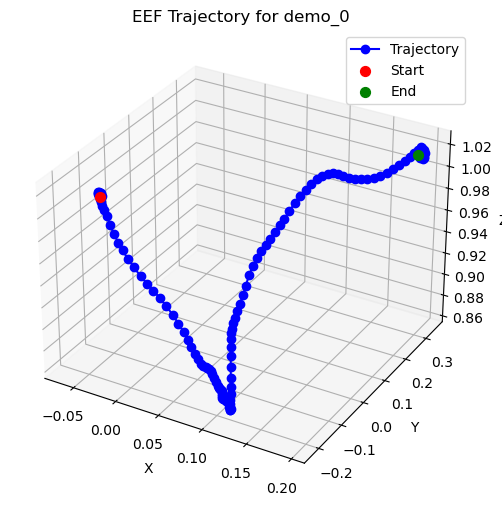

In [13]:
# Path to your dataset
#demo_path = f"/home/denizsen/awe/data/robomimic/datasets/{task}/ph/image_abs.hdf5"

# Open the HDF5 file
with h5py.File(demo_path, "r") as f:
    demo_id = "demo_0"
    eef_positions = f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:]

eef_positions = np.array(eef_positions)

# Plot 3D trajectory
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the full trajectory
ax.plot(eef_positions[:, 0], eef_positions[:, 1], eef_positions[:, 2], marker='o', color='blue', label='Trajectory')

# Highlight start position
ax.scatter(eef_positions[0, 0], eef_positions[0, 1], eef_positions[0, 2], color='red', s=50, label='Start')

# Highlight end position
ax.scatter(eef_positions[-1, 0], eef_positions[-1, 1], eef_positions[-1, 2], color='green', s=50, label='End')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"EEF Trajectory for {demo_id}")
ax.legend()

plt.show()


In [14]:
# Open the HDF5 file and extract EEF positions
demo_id = "demo_0"
with h5py.File(demo_path, "r") as f:
    eef_positions = f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:]

eef_positions = np.array(eef_positions)

# Main trajectory
trajectory = go.Scatter3d(
    x=eef_positions[:, 0],
    y=eef_positions[:, 1],
    z=eef_positions[:, 2],
    mode='lines+markers',
    marker=dict(size=3, color='blue'),
    line=dict(color='red', width=2),
    name='Trajectory'
)

# Start point (red)
start_point = go.Scatter3d(
    x=[eef_positions[0, 0]],
    y=[eef_positions[0, 1]],
    z=[eef_positions[0, 2]],
    mode='markers',
    marker=dict(size=6, color='red'),
    name='Start'
)

# End point (green)
end_point = go.Scatter3d(
    x=[eef_positions[-1, 0]],
    y=[eef_positions[-1, 1]],
    z=[eef_positions[-1, 2]],
    mode='markers',
    marker=dict(size=6, color='green'),
    name='End'
)

# Combine all traces
fig = go.Figure(data=[trajectory, start_point, end_point])

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title=f'EEF Trajectory for {demo_id}',
    width=800,
    height=600
)

fig.show()


### Automatic Waypoint Estimation

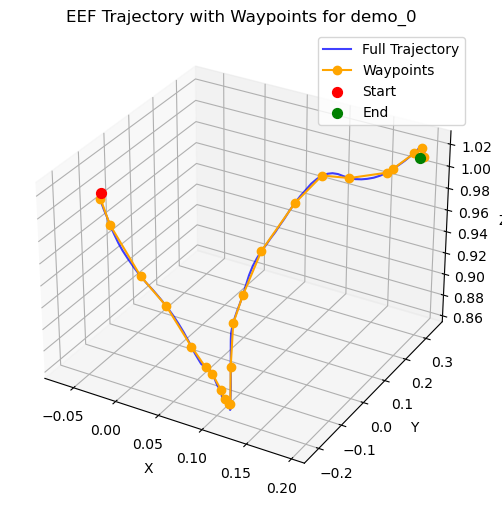

In [15]:
demo_id = "demo_0"
method = "dp"  # or "greedy", "backtrack"

with h5py.File(demo_path, "r") as f:
    # Full trajectory
    eef_positions = f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:]  # shape (T, 3)

    # Waypoint indices stored in the dataset
    waypoint_indices = f[f"data/{demo_id}/waypoints_{method}"][:]

eef_positions = np.array(eef_positions)
waypoint_indices = np.array(waypoint_indices, dtype=int)

# Get the EEF positions corresponding to waypoints
waypoint_positions = eef_positions[waypoint_indices]

# Plot 3D trajectory
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Full trajectory lightly
ax.plot(eef_positions[:, 0], eef_positions[:, 1], eef_positions[:, 2], color='blue', alpha=0.75, label='Full Trajectory')

# Waypoints overlay
ax.plot(waypoint_positions[:, 0], waypoint_positions[:, 1], waypoint_positions[:, 2], marker='o', color='orange', label='Waypoints')

# Start and end waypoints
ax.scatter(waypoint_positions[0, 0], waypoint_positions[0, 1], waypoint_positions[0, 2], color='red', s=50, label='Start')
ax.scatter(waypoint_positions[-1, 0], waypoint_positions[-1, 1], waypoint_positions[-1, 2], color='green', s=50, label='End')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"EEF Trajectory with Waypoints for {demo_id}")
ax.legend()
plt.show()


In [16]:
demo_id = "demo_0"
method = "dp"  # or "greedy", "backtrack"

with h5py.File(demo_path, "r") as f:
    # Full trajectory
    eef_positions = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:])
    
    # Waypoint indices stored in the dataset
    waypoint_indices = np.array(f[f"data/{demo_id}/waypoints_{method}"][:], dtype=int)
    waypoint_positions = eef_positions[waypoint_indices]

# Plot interactive 3D trajectory with waypoints
full_traj = go.Scatter3d(
    x=eef_positions[:, 0],
    y=eef_positions[:, 1],
    z=eef_positions[:, 2],
    mode='lines',
    line=dict(color='blue', width=2),
    name='Full Trajectory'
)

waypoints = go.Scatter3d(
    x=waypoint_positions[:, 0],
    y=waypoint_positions[:, 1],
    z=waypoint_positions[:, 2],
    mode='markers+lines',
    marker=dict(size=5, color='orange'),
    line=dict(color='orange', width=2),
    name='Waypoints'
)

start_point = go.Scatter3d(
    x=[waypoint_positions[0, 0]],
    y=[waypoint_positions[0, 1]],
    z=[waypoint_positions[0, 2]],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Start'
)

end_point = go.Scatter3d(
    x=[waypoint_positions[-1, 0]],
    y=[waypoint_positions[-1, 1]],
    z=[waypoint_positions[-1, 2]],
    mode='markers',
    marker=dict(size=8, color='green'),
    name='End'
)

fig = go.Figure(data=[full_traj, waypoints, start_point, end_point])

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title=f'EEF Trajectory with Waypoints ({method}) for {demo_id}',
    width=800,
    height=600
)

fig.show()


In [17]:
with h5py.File(demo_path, "r") as f:
    env_args = json.loads(f["data"].attrs["env_args"])
    print("control_freq:", env_args["env_kwargs"]["control_freq"])

control_freq: 20


In [18]:
with h5py.File(demo_path, "r") as f:
    pos = f["data/demo_0/abs_obs/robot0_eef_pos"][:]
    vel = f["data/demo_0/abs_obs/robot0_eef_vel_lin"][:]

# Estimate dt: pos_diff / vel should give dt
pos_diff = np.diff(pos, axis=0)  # shape (T-1, 3)
vel_mid = vel[:-1]               # shape (T-1, 3)

# For each axis, dt ≈ pos_diff / vel (avoid near-zero velocities)
mask = np.abs(vel_mid) > 0.01
dt_estimates = pos_diff[mask] / vel_mid[mask]
print(f"Estimated dt: {np.median(dt_estimates):.4f}s -> {1/np.median(dt_estimates):.1f} Hz")

Estimated dt: 0.0518s -> 19.3 Hz


### Examine Linear Velocities

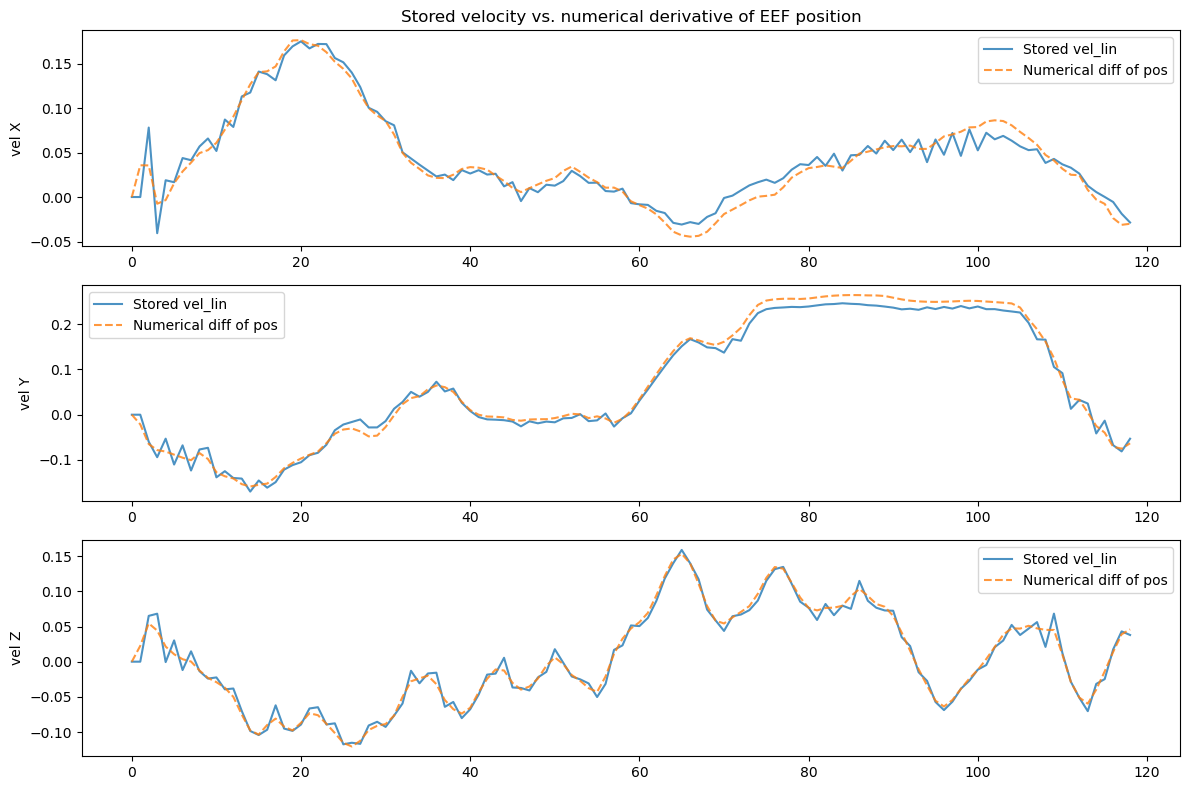

In [19]:
with h5py.File(demo_path, "r") as f:
    demo_id = "demo_0"
    eef_pos = f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:]
    eef_vel = f[f"data/{demo_id}/abs_obs/robot0_eef_vel_lin"][:]

# Numerical derivative (assuming dt=0.05 for 20Hz control, adjust if needed)
dt = 0.05 
eef_vel_numerical = np.gradient(eef_pos, dt, axis=0)

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
labels = ['X', 'Y', 'Z']
for i in range(3):
    axes[i].plot(eef_vel[:, i], label='Stored vel_lin', alpha=0.8)
    axes[i].plot(eef_vel_numerical[:, i], label='Numerical diff of pos', linestyle='--', alpha=0.8)
    axes[i].set_ylabel(f'vel {labels[i]}')
    axes[i].legend()
axes[0].set_title('Stored velocity vs. numerical derivative of EEF position')
plt.tight_layout()
plt.show()

### Spline Based Waypoint Estimation

In [20]:
def hermite_segment_error(
    gt_pos:    np.ndarray,  # (T, 3) full position trajectory
    gt_vel:    np.ndarray,  # (T, 3) velocities at each timestep
    start_idx: int,
    end_idx:   int,
) -> float:
    if end_idx <= start_idx:
        return 0.0

    # fit Hermite spline using only endpoint positions and velocities
    t      = np.array([start_idx, end_idx])
    spline = CubicHermiteSpline(t, gt_pos[t], gt_vel[t])

    # evaluate spline at every timestep in segment
    t_eval    = np.arange(start_idx, end_idx)   # exclude end (same as original [start:end])
    pred_pos  = spline(t_eval)
    gt_seg    = gt_pos[start_idx:end_idx]

    # point-to-spline distance (same philosophy as point_line_distance)
    errors = np.linalg.norm(pred_pos - gt_seg, axis=-1)

    return float(np.max(errors))  # max, matching total_traj_err

In [21]:
def dp_waypoint_selection_hermite(
    gt_pos:        np.ndarray,
    gt_vel:        np.ndarray,
    err_threshold: float = 0.005,
) -> list[int]:
    num_frames = len(gt_pos)
    initial_waypoints = [num_frames - 1]

    # DP table
    memo = {}
    for i in range(num_frames):
        memo[i] = (0, [])
    memo[1] = (1, [1])

    for i in range(1, num_frames):
        min_waypoints_required = float("inf")
        best_waypoints = []

        for k in range(1, i):
            error = hermite_segment_error(gt_pos, gt_vel, k, i)

            if error < err_threshold:
                subproblem_count, subproblem_wps = memo[k - 1]
                total_count = 1 + subproblem_count
                if total_count < min_waypoints_required:
                    min_waypoints_required = total_count
                    best_waypoints = subproblem_wps + [i]

        memo[i] = (min_waypoints_required, best_waypoints)

    _, waypoints = memo[num_frames - 1]
    waypoints = sorted(set(waypoints + initial_waypoints))
    print(f"Selected {len(waypoints)} waypoints")
    return waypoints

In [52]:
with h5py.File(demo_path, "r") as f:
    eef_positions  = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:])
    gt_vel         = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_vel_lin"][:]) * 0.05
    waypoint_indices = np.array(f[f"data/{demo_id}/waypoints_{method}"][:], dtype=int)

hermite_wps = dp_waypoint_selection_hermite(
    gt_pos=eef_positions,
    gt_vel=gt_vel,
    err_threshold=0.001,
)

Selected 24 waypoints


### Compare Reconstruction Error: Hermite Spline vs. and Linear

In [23]:
with h5py.File(demo_path, "r") as f:
    gt_pos = f["data/demo_0/abs_obs/robot0_eef_pos"][()]
    gt_vel = f["data/demo_0/abs_obs/robot0_eef_vel_lin"][()] * 0.05  # convert to units/timestep

In [24]:
for seg_len in [1, 2, 5, 10, 20]:
    # hermite
    h_err = hermite_segment_error(gt_pos, gt_vel, 0, seg_len)
    
    # linear
    seg = gt_pos[0:seg_len+1]
    l_err = max(point_line_distance(seg[i], seg[0], seg[-1]) for i in range(len(seg)))
    
    print(f"segment length {seg_len:3d}: hermite = {h_err:.6f} | linear = {l_err:.6f}")

segment length   1: hermite = 0.000000 | linear = nan
segment length   2: hermite = 0.000925 | linear = 0.000000
segment length   5: hermite = 0.002877 | linear = 0.003111
segment length  10: hermite = 0.005280 | linear = 0.005846
segment length  20: hermite = 0.012065 | linear = 0.020497


/home/denizsen/awe/waypoint_extraction/traj_reconstruction.py:20: RuntimeWarning:

invalid value encountered in double_scalars



### Visualise Hermite Spline

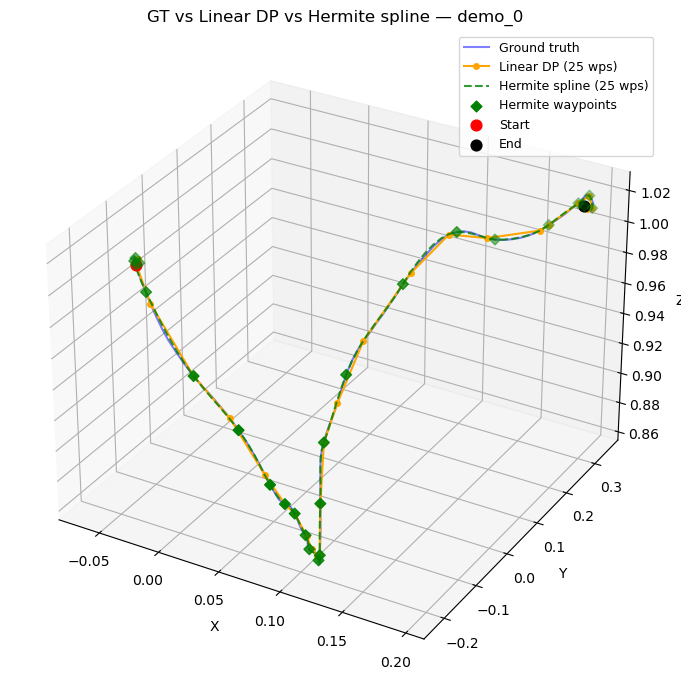

In [25]:
demo_id = "demo_0"
method  = "dp"

with h5py.File(demo_path, "r") as f:
    eef_positions    = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:])
    gt_vel           = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_vel_lin"][:]) * 0.05
    waypoint_indices = np.array(f[f"data/{demo_id}/waypoints_{method}"][:], dtype=int)

waypoint_positions = eef_positions[waypoint_indices]

# build hermite spline reconstruction
hermite_wps_full = sorted(set(hermite_wps + [0]))
hermite_pred = np.zeros_like(eef_positions)
for i in range(len(hermite_wps_full) - 1):
    s, e   = hermite_wps_full[i], hermite_wps_full[i+1]
    spline = CubicHermiteSpline(np.array([s, e]), eef_positions[[s, e]], gt_vel[[s, e]])
    t_eval = np.arange(s, e+1)
    hermite_pred[t_eval] = spline(t_eval)

hermite_positions = eef_positions[hermite_wps_full]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(*eef_positions.T,    color='blue',   alpha=0.5, lw=1.5, label='Ground truth')
ax.plot(*waypoint_positions.T, 'o-', color='orange', lw=1.5, ms=4, label=f'Linear DP ({len(waypoint_indices)} wps)')
ax.plot(*hermite_pred.T,     color='green',  alpha=0.8, lw=1.5, linestyle='--', label=f'Hermite spline ({len(hermite_wps_full)} wps)')
ax.scatter(*hermite_positions.T, color='green', s=30, marker='D', zorder=5, label='Hermite waypoints')

ax.scatter(*eef_positions[0],  color='red',   s=60, zorder=6, label='Start')
ax.scatter(*eef_positions[-1], color='black', s=60, zorder=6, label='End')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"GT vs Linear DP vs Hermite spline — {demo_id}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [26]:
hermite_wps = sorted(set(hermite_wps + [0]))
demo_id = "demo_0"
method  = "dp"

with h5py.File(demo_path, "r") as f:
    eef_positions  = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_pos"][:])
    gt_vel         = np.array(f[f"data/{demo_id}/abs_obs/robot0_eef_vel_lin"][:]) * 0.05
    waypoint_indices = np.array(f[f"data/{demo_id}/waypoints_{method}"][:], dtype=int)

waypoint_positions = eef_positions[waypoint_indices]

# build hermite spline reconstruction
hermite_pred = np.zeros_like(eef_positions)
for i in range(len(hermite_wps) - 1):
    s, e   = hermite_wps[i], hermite_wps[i+1]
    spline = CubicHermiteSpline(
        np.array([s, e]),
        eef_positions[[s, e]],
        gt_vel[[s, e]]
    )
    t_eval = np.arange(s, e+1)
    hermite_pred[t_eval] = spline(t_eval)

hermite_positions = eef_positions[hermite_wps]

# traces
full_traj = go.Scatter3d(
    x=eef_positions[:, 0], y=eef_positions[:, 1], z=eef_positions[:, 2],
    mode='lines', line=dict(color='blue', width=2), name='Ground truth'
)
linear_wp = go.Scatter3d(
    x=waypoint_positions[:, 0], y=waypoint_positions[:, 1], z=waypoint_positions[:, 2],
    mode='markers+lines', marker=dict(size=5, color='orange'), line=dict(color='orange', width=2),
    name=f'Linear DP ({len(waypoint_indices)} wps)'
)
hermite_traj = go.Scatter3d(
    x=hermite_pred[:, 0], y=hermite_pred[:, 1], z=hermite_pred[:, 2],
    mode='lines', line=dict(color='green', width=2), name=f'Hermite spline ({len(hermite_wps)} wps)'
)
hermite_wp = go.Scatter3d(
    x=hermite_positions[:, 0], y=hermite_positions[:, 1], z=hermite_positions[:, 2],
    mode='markers', marker=dict(size=5, color='green', symbol='diamond'),
    name='Hermite waypoints'
)
start_point = go.Scatter3d(
    x=[eef_positions[0, 0]], y=[eef_positions[0, 1]], z=[eef_positions[0, 2]],
    mode='markers', marker=dict(size=8, color='red'), name='Start'
)
end_point = go.Scatter3d(
    x=[eef_positions[-1, 0]], y=[eef_positions[-1, 1]], z=[eef_positions[-1, 2]],
    mode='markers', marker=dict(size=8, color='black'), name='End'
)

fig = go.Figure(data=[full_traj, linear_wp, hermite_traj, hermite_wp, start_point, end_point])
fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    title=f'GT vs Linear DP vs Hermite spline — {demo_id}',
    width=800, height=600
)
fig.show()

### Save hermite spline waypoints for executen later on

In [27]:
def save_waypoints_hermite(dataset_path, start_idx=0, end_idx=199, err_threshold=0.005, save=True):
    f = h5py.File(dataset_path, "r+" if save else "r")
    demos = list(f["data"].keys())
    inds  = np.argsort([int(elem[5:]) for elem in demos])
    demos = [demos[i] for i in inds]
    
    results = {}
    for idx in tqdm(range(start_idx, end_idx + 1)):
        ep      = demos[idx]
        gt_pos  = f[f"data/{ep}/abs_obs/robot0_eef_pos"][()]
        gt_vel  = f[f"data/{ep}/abs_obs/robot0_eef_vel_lin"][()] * 0.002
        abs_actions = f[f"data/{ep}/abs_actions"][()]
        
        # trim obs to match actions length obs has one extra terminal frame
        # removing it shouldnt matter 
        traj_len = len(abs_actions)
        gt_pos   = gt_pos[:traj_len]
        gt_vel   = gt_vel[:traj_len]
        
        waypoints = dp_waypoint_selection_hermite(gt_pos, gt_vel, err_threshold)
        
        if save:
            key = f"data/{ep}/waypoints_hermite"
            if key in f: del f[key]
            f[key] = waypoints
        else:
            results[ep] = waypoints
    
    f.close()
    if not save:
        return results

# test on first 5
results = save_waypoints_hermite(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=5,
    err_threshold=0.001,
    save=False,
)

for ep, wps in results.items():
    print(f"{ep}: {len(wps)} waypoints -> {wps}")

  0%|          | 0/6 [00:00<?, ?it/s]

Selected 39 waypoints
Selected 39 waypoints
Selected 39 waypoints
Selected 33 waypoints
Selected 37 waypoints
Selected 47 waypoints
demo_0: 39 waypoints -> [2, 5, 8, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 47, 51, 56, 59, 62, 65, 68, 71, 74, 77, 80, 83, 86, 89, 92, 95, 98, 101, 104, 107, 109, 112, 115, 117]
demo_1: 39 waypoints -> [2, 5, 8, 11, 13, 16, 18, 21, 24, 27, 30, 34, 37, 40, 44, 48, 51, 55, 59, 64, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 95, 97, 100, 103, 106, 109, 111, 114, 117]
demo_2: 39 waypoints -> [3, 5, 8, 11, 14, 16, 19, 22, 25, 28, 30, 33, 36, 39, 42, 46, 50, 54, 58, 62, 65, 68, 70, 72, 75, 78, 81, 84, 87, 90, 93, 95, 98, 101, 104, 106, 108, 110, 112]
demo_3: 33 waypoints -> [2, 4, 7, 10, 13, 16, 19, 22, 25, 29, 33, 36, 39, 43, 47, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 83, 86, 88, 91, 93, 95, 97]
demo_4: 37 waypoints -> [2, 5, 7, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 58, 60, 62, 65, 68, 71, 74, 77, 80, 83, 86, 89, 91, 93, 95, 97,

### Create Environment

In [28]:
env = make(
    env_name,
    robots="Panda",
    controller_configs=load_controller_config(default_controller="OSC_POSE"),
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=480,
    camera_widths=640,
    control_freq=20,
    horizon=200,
    )

In [29]:
def random_action(env, step):
    # step is placehoder
    return np.random.uniform(-1, 1, env.action_spec[0].shape)

In [71]:
def stream_simulation_notebook(env, policy, max_steps=100):
    obs = env.reset()
    
    # Only call reset_env if the policy has this method (e.g., it's a policy object)
    if hasattr(policy, 'reset_env'):
        policy.reset_env(env)
    
    output = widgets.Output()
    display(output)
    #print("Streaming started!")
    step = 0
    
    while step < max_steps:
        # If policy is a function, call it directly; if it's an object, call it
        if callable(policy):
            action = policy(env, step)
        else:
            action = policy.get_action(obs)
            
        obs, reward, done, info = env.step(action)
        
        if 'agentview_image' in obs:
            frame = obs['agentview_image'][::-1, :, :]
            pil_img = Image.fromarray(frame)
            buf = BytesIO()
            pil_img.save(buf, format='JPEG', quality=25)
            with output:
                output.clear_output(wait=True)
                display(IPImage(data=buf.getvalue()))
        
        #print(f"Step {step}, Reward: {reward:.3f}")
        step += 1
        
        if done:
            break
    
    env.close()
    print("Simulation ended")

In [32]:
# Run sim
stream_simulation_notebook(env=env, policy=random_action, max_steps=100)

Output()

KeyboardInterrupt: 

### Execute human demo
Note: Human demo is in delta action

In [ ]:
class WaypointPolicy:
    """Execute waypoints using absolute control"""
    def __init__(self, demo_path, demo_name="demo_0", method="dp", hold_steps=10):
        with h5py.File(demo_path, "r") as f:
            demo = f[f"data/{demo_name}"]
            
            # Load waypoint indices
            self.waypoint_indices = demo[f"waypoints_{method}"][:]
            
            # Load absolute actions at waypoint indices
            abs_actions = demo["abs_actions"][:]
            self.waypoint_actions = abs_actions[self.waypoint_indices]
            
            # Load initial state
            self.initial_state = demo["states"][0]
            
            # Hold each waypoint for N steps
            self.hold_steps = hold_steps
            
            print(f"Loaded {len(self.waypoint_actions)} waypoints")
    
    def reset_env(self, env):
        env.sim.set_state_from_flattened(self.initial_state)
        env.sim.forward()
    
    def __call__(self, env, step):
        """Return waypoint action, holding each for hold_steps"""
        waypoint_idx = min(step // self.hold_steps, len(self.waypoint_actions) - 1)
        return self.waypoint_actions[waypoint_idx]


# Setup environment with abs control
controller_config = {
    "type": "OSC_POSE",
    "control_delta": False,  # Abs control so false
    "interpolation": "linear",
    "ramp_ratio": 0.2,
    "kp": 150,
    "damping_ratio": 1,
    "impedance_mode": "fixed",
    "uncouple_pos_ori": True,
    "multiplier": 1.0, 
}

env = make(
    env_name,
    robots="Panda",
    controller_configs=controller_config,
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=480,
    camera_widths=640,
    control_freq=20,
    horizon=200,
)

print(env.robots[0].controller.name)

# Execute waypoints
waypoint_policy = WaypointPolicy(demo_path, demo_name="demo_0", method="dp", hold_steps=5)
stream_simulation_notebook(env=env, policy=waypoint_policy, max_steps=100)

OSC_POSE
Loaded 25 waypoints


Output()

KeyboardInterrupt: 

### Execute DP Linear Waypoint
Note: Absolute action

In [34]:
class WaypointPolicy:
    """Execute waypoints using absolute control"""
    def __init__(self, demo_path, demo_name="demo_0", method="dp", hold_steps=10):
        with h5py.File(demo_path, "r") as f:
            demo = f[f"data/{demo_name}"]
            
            # Load waypoint indices
            self.waypoint_indices = demo[f"waypoints_{method}"][:]
            
            # Load absolute actions at waypoint indices
            abs_actions = demo["abs_actions"][:]
            self.waypoint_actions = abs_actions[self.waypoint_indices]
            
            # Load initial state
            self.initial_state = demo["states"][0]
            
            # Hold each waypoint for N steps
            self.hold_steps = hold_steps
            
            print(f"Loaded {len(self.waypoint_actions)} waypoints")
    
    def reset_env(self, env):
        env.sim.set_state_from_flattened(self.initial_state)
        env.sim.forward()
    
    def __call__(self, env, step):
        """Return waypoint action, holding each for hold_steps"""
        waypoint_idx = min(step // self.hold_steps, len(self.waypoint_actions) - 1)
        return self.waypoint_actions[waypoint_idx]


# Setup environment with abs control
controller_config = {
    "type": "OSC_POSE",
    "control_delta": False,  # abs control so delta false
    "interpolation": "linear",
    "ramp_ratio": 0.2,
    "multiplier": 1.0, 
    
}

env = make(
    env_name,
    robots="Panda",
    controller_configs=controller_config,
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=480,
    camera_widths=640,
    control_freq=20,
    horizon=200,
)

# Execute waypoints
waypoint_policy = WaypointPolicy(demo_path, demo_name="demo_0", method="dp", hold_steps=5)
stream_simulation_notebook(env=env, policy=waypoint_policy, max_steps=200)

Loaded 25 waypoints


Output()

KeyboardInterrupt: 

### Execute Hermite Spline DP Waypoint

In [ ]:
# get waypoints for demo_0 without saving
results = save_waypoints_hermite(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=0,
    err_threshold=0.005,
    save=False,
)
waypoints_demo0 = results["demo_0"]

# modify WaypointPolicy to accept pre-computed waypoints
class WaypointPolicy:
    def __init__(self, demo_path, demo_name="demo_0", method="hermite", waypoint_indices=None):
        with h5py.File(demo_path, "r") as f:
            demo        = f[f"data/{demo_name}"]
            abs_actions = demo["abs_actions"][:]
            abs_vel     = demo["abs_obs/robot0_eef_vel_lin"][:] * 0.002
            gt_pos      = demo["abs_obs/robot0_eef_pos"][:]

            # use pre-computed waypoints if provided, else load from HDF5
            if waypoint_indices is not None:
                self.waypoint_indices = np.array(waypoint_indices)
            else:
                self.waypoint_indices = demo[f"waypoints_{method}"][:]

            self.waypoint_actions = abs_actions[self.waypoint_indices]
            self.waypoint_vels    = abs_vel[self.waypoint_indices]
            self.initial_state    = demo["states"][0]
            # sanity check
            print(f"abs_actions[wp0, :3]: {self.waypoint_actions[0, :3]}")
            print(f"gt_pos[wp0]:          {gt_pos[self.waypoint_indices[0]]}")
            print(f"Loaded {len(self.waypoint_actions)} waypoints")

    def reset_env(self, env):
        env.sim.set_state_from_flattened(self.initial_state)
        env.sim.forward()

    def __call__(self, env, step):
        waypoint_idx = np.searchsorted(self.waypoint_indices, step, side='right')
        waypoint_idx = min(waypoint_idx, len(self.waypoint_actions) - 1)
        
        # debug: print tracking error when waypoint switches
        #if not hasattr(self, '_prev_wp_idx'):
        #    self._prev_wp_idx = -1
        #if waypoint_idx != self._prev_wp_idx and self._prev_wp_idx >= 0:
        #    ee_pos = env.robots[0].controller.ee_pos
        #    target = self.waypoint_actions[self._prev_wp_idx, :3]
        #    err = np.linalg.norm(ee_pos - target)
        #    print(f"wp {self._prev_wp_idx:2d}→{waypoint_idx:2d} at step {step:3d} | tracking error: {err:.4f}m")
        #self._prev_wp_idx = waypoint_idx

        ctrl = env.robots[0].controller
        ctrl._pending_goal_vel = self.waypoint_vels[waypoint_idx]
        return self.waypoint_actions[waypoint_idx]



# use pre-computed waypoints directly
waypoint_policy = WaypointPolicy(
    demo_path,
    demo_name="demo_0",
    waypoint_indices=waypoints_demo0,
)

# Setup environment with abs control
controller_config = {
    "type": "OSC_POSE",
    "control_delta": False,  # abs control so delta false
    "interpolation": "hermite_spline",
    "ramp_ratio": 0.2,
    "multiplier": 1.0, 
}

env = make(
    env_name,
    robots="Panda",
    controller_configs=controller_config,
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=480,
    camera_widths=640,
    control_freq=20,
    horizon=200,
)

robot = env.robots[0]
controller = robot.controller
print(controller.__class__.__name__)
print(type(controller.interpolator_pos))
print(controller.interpolator_pos.order)

stream_simulation_notebook(env=env, policy=waypoint_policy, max_steps=250)

  0%|          | 0/1 [00:00<?, ?it/s]

Selected 22 waypoints
abs_actions[wp0, :3]: [-0.06121413 -0.10464894  1.00070843]
gt_pos[wp0]:          [-0.0623683  -0.10049958  1.00056307]
Loaded 22 waypoints
OperationalSpaceController
<class 'robosuite.controllers.interpolators.hermite_spline_interpolator.HermiteSplineInterpolator'>
1


KeyboardInterrupt: 

### Compare execution of linear vs hermite spline

In [101]:
# fetch demo length to run stream for exact number of demo
with h5py.File(demo_path, "r") as f:
    demo_len = f["data/demo_0/states"].shape[0]
print('demo_len:', demo_len)

# Modified stream to record EEF positions
def stream_and_record(env, policy, max_steps=200):
    obs = env.reset()
    policy.reset_env(env)
    eef_positions = []
    
    for step in range(max_steps):
        action = policy(env, step)
        obs, reward, done, info = env.step(action)
        # record actual EEF position at each sim step
        eef_positions.append(env.robots[0].controller.ee_pos.copy())
        #if done:
        #    break
    
    return np.array(eef_positions)

controller_config_hermite = {
    "type": "OSC_POSE",
    "control_delta": False,  # abs control so delta false
    "interpolation": "hermite_spline",
    "ramp_ratio": 1.0,
    "multiplier": 10.0, 
}

env_hermite = make(
    env_name,
    robots="Panda",
    controller_configs=controller_config_hermite,
    has_renderer=False,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    camera_names=["agentview"],
    camera_heights=480,
    camera_widths=640,
    control_freq=20,
    horizon=500,
)

# get waypoints for demo_0 without saving
waypoints_hermite_dp = save_waypoints_hermite(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=0,
    err_threshold=0.005,
    save=False,
)
waypoints_demo0_hermite = waypoints_hermite_dp["demo_0"]

waypoints_lin_dp = save_waypoints(
    dataset_path=demo_path,
    start_idx=0,
    end_idx=0,
    err_threshold=0.005,
    save=False,
)

waypoints_demo0_lin = waypoints_lin_dp["demo_0"]

# run hermite
waypoint_policy_hermite = WaypointPolicy(
    demo_path, demo_name="demo_0", method='hermite',
    waypoint_indices=waypoints_demo0_hermite
)
hermite_traj = stream_and_record(env_hermite, waypoint_policy_hermite, demo_len)

# run linear — same waypoints, different controller
controller_config_linear = {
    "type": "OSC_POSE",
    "control_delta": False,
    "interpolation": "linear",
    "ramp_ratio": 0.2,
    "multiplier": 1.0,
}
env_lin = make(env_name, robots="Panda", controller_configs=controller_config_linear,
               has_renderer=False, has_offscreen_renderer=True,
               use_camera_obs=False, control_freq=20, horizon=500)

waypoint_policy_linear = WaypointPolicy(
    demo_path, demo_name="demo_0", method='linear',
    waypoint_indices=waypoints_demo0_hermite
)
linear_traj = stream_and_record(env_lin, waypoint_policy_linear, demo_len)

# RMSE vs ground truth
with h5py.File(demo_path, "r") as f:
    gt_pos = f["data/demo_0/abs_obs/robot0_eef_pos"][:demo_len]

def rmse(pred, gt):
    return np.sqrt(np.mean(np.sum((pred - gt)**2, axis=1)))

print(f"Hermite RMSE vs GT: {rmse(hermite_traj, gt_pos):.4f}m")
print(f"Linear  RMSE vs GT: {rmse(linear_traj,  gt_pos):.4f}m")

demo_len: 118


  0%|          | 0/1 [00:00<?, ?it/s]

Selected 22 waypoints

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name PickPlaceCan
Action size is 7


Saving waypoints:   0%|          | 0/1 [00:00<?, ?it/s]

Minimum number of waypoints: 25 	Trajectory Error: 5.516550207372527e-09
waypoint positions: [3, 9, 14, 20, 24, 29, 34, 38, 44, 51, 54, 60, 65, 71, 75, 80, 87, 92, 97, 103, 104, 108, 111, 114, 117]
Average waypoints: 25.0, average frames: 118.0, waypoint ratio: 4.72x
abs_actions[wp0, :3]: [-0.06121413 -0.10464894  1.00070843]
gt_pos[wp0]:          [-0.0623683  -0.10049958  1.00056307]
Loaded 22 waypoints
wp  0→ 1 at step   5 | tracking error: 0.0006m
wp  1→ 2 at step  11 | tracking error: 0.0002m
wp  2→ 3 at step  15 | tracking error: 0.0004m


KeyboardInterrupt: 

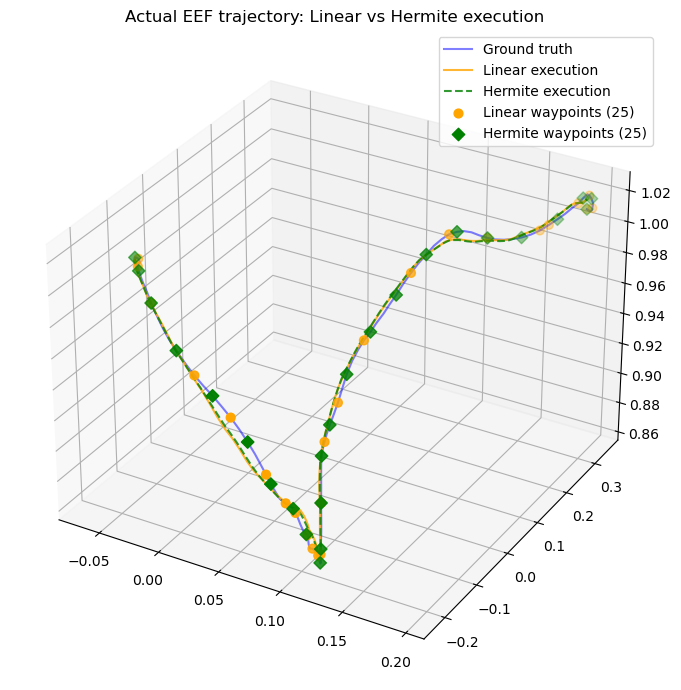

In [100]:
# plot both
with h5py.File(demo_path, "r") as f:
    gt_pos = f["data/demo_0/abs_obs/robot0_eef_pos"][:len(hermite_traj)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(*gt_pos.T,       color='blue',   alpha=0.5, lw=1.5, label='Ground truth')
ax.plot(*linear_traj.T,  color='orange', alpha=0.8, lw=1.5, label='Linear execution')
ax.plot(*hermite_traj.T, color='green',  alpha=0.8, lw=1.5, linestyle='--', label='Hermite execution')
ax.scatter(*gt_pos[waypoints_demo0_lin].T,    color='orange', s=40, marker='o', zorder=5, label=f'Linear waypoints ({len(waypoints_demo0_lin)})')
ax.scatter(*gt_pos[waypoints_demo0_hermite].T, color='green',  s=40, marker='D', zorder=5, label=f'Hermite waypoints ({len(waypoints_demo0_hermite)})')
ax.legend()
ax.set_title("Actual EEF trajectory: Linear vs Hermite execution")
plt.tight_layout()
plt.show()

In [ ]:
with h5py.File(demo_path, "r") as f:
    gt_pos = np.array(f["data/demo_0/abs_obs/robot0_eef_pos"][:])

#n = min(len(hermite_traj), len(linear_traj), len(gt_pos))

full_traj = go.Scatter3d(
    x=gt_pos[:, 0], y=gt_pos[:, 1], z=gt_pos[:, 2],
    mode='lines', line=dict(color='blue', width=2), name='Ground truth'
)
linear_exec = go.Scatter3d(
    x=linear_traj[:, 0], y=linear_traj[:, 1], z=linear_traj[:, 2],
    mode='lines', line=dict(color='orange', width=2), name=f'Linear execution'
)
hermite_exec = go.Scatter3d(
    x=hermite_traj[:, 0], y=hermite_traj[:, 1], z=hermite_traj[:, 2],
    mode='lines', line=dict(color='green', width=2, dash='dash'), name=f'Hermite execution'
)
linear_wps = go.Scatter3d(
    x=gt_pos[waypoints_demo0_lin, 0], y=gt_pos[waypoints_demo0_lin, 1], z=gt_pos[waypoints_demo0_lin, 2],
    mode='markers', marker=dict(size=5, color='orange', symbol='circle'),
    name=f'Linear waypoints ({len(waypoints_demo0_lin)})'
)
hermite_wps_plot = go.Scatter3d(
    x=gt_pos[waypoints_demo0_hermite, 0], y=gt_pos[waypoints_demo0_hermite, 1], z=gt_pos[waypoints_demo0_hermite, 2],
    mode='markers', marker=dict(size=5, color='green', symbol='diamond'),
    name=f'Hermite waypoints ({len(waypoints_demo0_hermite)})'
)
start_pt = go.Scatter3d(
    x=[gt_pos[0, 0]], y=[gt_pos[0, 1]], z=[gt_pos[0, 2]],
    mode='markers', marker=dict(size=8, color='red'), name='Start'
)
end_pt = go.Scatter3d(
    x=[gt_pos[-1, 0]], y=[gt_pos[-1, 1]], z=[gt_pos[-1, 2]],
    mode='markers', marker=dict(size=8, color='black'), name='End'
)

fig = go.Figure(data=[full_traj, linear_exec, hermite_exec, linear_wps, hermite_wps_plot, start_pt, end_pt])
fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    title=f'GT vs Linear DP vs Hermite execution — demo_0 '
          f'(linear: {len(waypoints_demo0_lin)} wps, hermite: {len(waypoints_demo0_hermite)} wps)',
    width=900, height=650
)
fig.show()